In [4]:
#importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import datetime as dt

sns.set()

In [5]:
#import dataset
df = pd.read_csv("../Data/Jewelry_Dataset.csv")

## Data cleaning and EDA

In [6]:
#peeking dataset
df.head(5)

,2018-12-01 11:40:29 UTC,1924719191579951782,1842195256808833386,1,1806829201890738522,jewelry.earring,0,561.51,1515915625207851155,Unnamed: 9,red,gold,diamond
0,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN


In [7]:
df.columns=[
"Order_date",
"Order_ID",
"product_ID",
"SKU_quantity",
"category_ID",
"category_alias",
"brand_ID",
"Price_USD",
"user_ID",
"gender",
"main_color",
"main_metal",
"main_gem"]

In [8]:
df.head(10)

,Order_date,Order_ID,product_ID,SKU_quantity,category_ID,category_alias,brand_ID,Price_USD,user_ID,gender,main_color,main_metal,main_gem
0,2018-12-01 17:38:31 UTC,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42 UTC,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02 UTC,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19 UTC,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34 UTC,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN
5,2018-12-02 22:09:34 UTC,1925760595336888995,1600021442638905547,1,1.806829e+18,jewelry.earring,0.0,150.55,1.515916e+18,NaN,red,gold,diamond
6,2018-12-02 22:16:20 UTC,1925764002260976330,1835566854106513435,1,1.806829e+18,jewelry.earring,0.0,83.42,1.515916e+18,NaN,white,gold,fianit
7,2018-12-03 07:03:49 UTC,1926029494397698277,1811798112444875309,1,1.806829e+18,jewelry.pendant,2.0,60.27,1.515916e+18,f,red,gold,pearl
8,2018-12-03 09:48:34 UTC,1926112416450478161,1836278824443052965,1,1.806829e+18,jewelry.earring,1.0,217.40,1.515916e+18,NaN,red,gold,diamond
9,2018-12-03 09:48:34 UTC,1926112416450478161,1877637299521454325,1,1.806829e+18,jewelry.ring,1.0,180.71,1.515916e+18,NaN,white,gold,diamond


In [9]:
#check data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95910 entries, 0 to 95909
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order_date      95910 non-null  object 
 1   Order_ID        95910 non-null  int64  
 2   product_ID      95910 non-null  int64  
 3   SKU_quantity    95910 non-null  int64  
 4   category_ID     90558 non-null  float64
 5   category_alias  85977 non-null  object 
 6   brand_ID        91125 non-null  float64
 7   Price_USD       90558 non-null  float64
 8   user_ID         90558 non-null  float64
 9   gender          47743 non-null  object 
 10  main_color      88250 non-null  object 
 11  main_metal      90448 non-null  object 
 12  main_gem        61852 non-null  object 
dtypes: float64(4), int64(3), object(6)
memory usage: 9.5+ MB


In [10]:
#check for data description
df.describe(include="all")

,Order_date,Order_ID,product_ID,SKU_quantity,category_ID,category_alias,brand_ID,Price_USD,user_ID,gender,main_color,main_metal,main_gem
count,95910,9.591000e+04,9.591000e+04,95910.0,9.055800e+04,85977,9.112500e+04,90558.000000,9.055800e+04,47743,88250,90448,61852
unique,74504,NaN,NaN,NaN,NaN,218,NaN,NaN,NaN,2,5,3,30
top,2020-10-17 12:58:28 UTC,NaN,NaN,NaN,NaN,jewelry.earring,NaN,NaN,NaN,f,red,gold,diamond
freq,26,NaN,NaN,NaN,NaN,29051,NaN,NaN,NaN,47379,69510,89081,29609
mean,NaN,2.485191e+18,1.815970e+18,1.0,1.805947e+18,NaN,8.891036e+16,362.213017,1.512644e+18,NaN,NaN,NaN,NaN
std,NaN,1.934750e+17,2.136814e+17,0.0,2.083954e+16,NaN,3.559651e+17,444.157665,2.374776e+16,NaN,NaN,NaN,NaN
min,NaN,1.924899e+18,1.313551e+18,1.0,1.313678e+18,NaN,0.000000e+00,0.990000,1.313554e+18,NaN,NaN,NaN,NaN
25%,NaN,2.379732e+18,1.515966e+18,1.0,1.806829e+18,NaN,0.000000e+00,145.620000,1.515916e+18,NaN,NaN,NaN,NaN
50%,NaN,2.524282e+18,1.956664e+18,1.0,1.806829e+18,NaN,1.000000e+00,258.770000,1.515916e+18,NaN,NaN,NaN,NaN
75%,NaN,2.644347e+18,1.956664e+18,1.0,1.806829e+18,NaN,1.000000e+00,431.370000,1.515916e+18,NaN,NaN,NaN,NaN


In [11]:
#convert order date column to datetime
df["Order_date"] = pd.to_datetime(df["Order_date"], errors='coerce')

In [12]:
df.head(10)

,Order_date,Order_ID,product_ID,SKU_quantity,category_ID,category_alias,brand_ID,Price_USD,user_ID,gender,main_color,main_metal,main_gem
0,2018-12-01 17:38:31+00:00,1924899396621697920,1806829193678291446,1,1.806829e+18,NaN,NaN,212.14,1.515916e+18,NaN,yellow,gold,NaN
1,2018-12-02 13:53:42+00:00,1925511016616034733,1842214461889315556,1,1.806829e+18,jewelry.pendant,1.0,54.66,1.515916e+18,f,white,gold,sapphire
2,2018-12-02 17:44:02+00:00,1925626951238681511,1835566849434059453,1,1.806829e+18,jewelry.pendant,0.0,88.90,1.515916e+18,f,red,gold,diamond
3,2018-12-02 21:30:19+00:00,1925740842841014667,1873936840742928865,1,1.806829e+18,jewelry.necklace,0.0,417.67,1.515916e+18,NaN,red,gold,amethyst
4,2018-12-02 22:09:34+00:00,1925760595336888995,1835566854827934449,1,1.806829e+18,jewelry.earring,1.0,102.27,1.515916e+18,NaN,red,gold,NaN
5,2018-12-02 22:09:34+00:00,1925760595336888995,1600021442638905547,1,1.806829e+18,jewelry.earring,0.0,150.55,1.515916e+18,NaN,red,gold,diamond
6,2018-12-02 22:16:20+00:00,1925764002260976330,1835566854106513435,1,1.806829e+18,jewelry.earring,0.0,83.42,1.515916e+18,NaN,white,gold,fianit
7,2018-12-03 07:03:49+00:00,1926029494397698277,1811798112444875309,1,1.806829e+18,jewelry.pendant,2.0,60.27,1.515916e+18,f,red,gold,pearl
8,2018-12-03 09:48:34+00:00,1926112416450478161,1836278824443052965,1,1.806829e+18,jewelry.earring,1.0,217.40,1.515916e+18,NaN,red,gold,diamond
9,2018-12-03 09:48:34+00:00,1926112416450478161,1877637299521454325,1,1.806829e+18,jewelry.ring,1.0,180.71,1.515916e+18,NaN,white,gold,diamond


In [13]:
#check for duplicate values
duplicates = len(df.loc[df.duplicated()])

In [14]:
print(f"Number of duplicated values is",duplicates)

Number of duplicated values is 2589


In [15]:
#check for missing values
df.isnull().sum()

Order_date            0
Order_ID              0
product_ID            0
SKU_quantity          0
category_ID        5352
category_alias     9933
brand_ID           4785
Price_USD          5352
user_ID            5352
gender            48167
main_color         7660
main_metal         5462
main_gem          34058
dtype: int64

In [16]:
# drop columns not relevant for this course
dropped_columns = ["category_ID","Order_ID","product_ID","user_ID","Order_date","SKU_quantity"]

data_with_drop_column = df.drop(columns = dropped_columns)

In [17]:
#peek new data
data_with_drop_column.head(10)

,category_alias,brand_ID,Price_USD,gender,main_color,main_metal,main_gem
0,NaN,NaN,212.14,NaN,yellow,gold,NaN
1,jewelry.pendant,1.0,54.66,f,white,gold,sapphire
2,jewelry.pendant,0.0,88.90,f,red,gold,diamond
3,jewelry.necklace,0.0,417.67,NaN,red,gold,amethyst
4,jewelry.earring,1.0,102.27,NaN,red,gold,NaN
5,jewelry.earring,0.0,150.55,NaN,red,gold,diamond
6,jewelry.earring,0.0,83.42,NaN,white,gold,fianit
7,jewelry.pendant,2.0,60.27,f,red,gold,pearl
8,jewelry.earring,1.0,217.40,NaN,red,gold,diamond
9,jewelry.ring,1.0,180.71,NaN,white,gold,diamond


In [18]:
#missing values
data_with_drop_column.isna().sum()

category_alias     9933
brand_ID           4785
Price_USD          5352
gender            48167
main_color         7660
main_metal         5462
main_gem          34058
dtype: int64

In [19]:
data_with_drop_column.nunique()

category_alias     218
brand_ID          2537
Price_USD         3166
gender               2
main_color           5
main_metal           3
main_gem            30
dtype: int64

In [20]:
#clean various columns
checked_columns = ["category_alias", "brand_ID", "gender", "main_color", "main_metal","main_gem"]

for col in checked_columns:
    print(f"\nTop values for {col} ")
    print(data_with_drop_column[col].value_counts(dropna=False).head(20))


Top values for category_alias 
category_alias
jewelry.earring       29051
jewelry.ring          28300
jewelry.pendant       13088
NaN                    9933
jewelry.bracelet       6188
0.00                   4392
jewelry.necklace       2361
jewelry.brooch         1288
jewelry.souvenir        170
electronics.clocks      167
40.82                    54
231.51                   45
261.64                   43
323.60                   33
154.66                   32
338.36                   30
236.58                   29
131.92                   24
863.67                   23
644.66                   21
Name: count, dtype: int64

Top values for brand_ID 
brand_ID
0.000000e+00    44599
1.000000e+00    32022
2.000000e+00     8966
NaN              4785
1.515916e+18      147
1.515916e+18      104
1.515916e+18       74
4.000000e+00       65
3.000000e+00       58
6.000000e+00       56
1.515916e+18       37
1.515916e+18       34
1.515916e+18       34
1.515916e+18       31
1.515916e+18       30
1.

In [21]:
import pandas as pd
import numpy as np

In [22]:
#CLEANING RECORDS IN THE VARIOUS COLUMNS

#dropping NaNs and 0.00 from category_alias
data_with_drop_column = data_with_drop_column[~data_with_drop_column['category_alias'].isin([np.nan,"nan", "0.00"])]

#replace NaNs with unknown for brand_ID
data_with_drop_column["brand_ID"] = data_with_drop_column["brand_ID"].fillna("unknown")

#replace NaNs with unknown for gender
data_with_drop_column["gender"] = data_with_drop_column["gender"].fillna("unknown")

#replace unknown-color and NaN with unknown for main_color
data_with_drop_column["main_color"] = data_with_drop_column["main_color"].replace('unknown-color','unknown')
data_with_drop_column["main_color"] = data_with_drop_column["main_color"].fillna('unknown')

#replace NaNs with unknown for main_metal
data_with_drop_column["main_metal"] = data_with_drop_column["main_metal"].fillna('unknown')

#replace NaNs with unknown for main_gem
data_with_drop_column["main_gem"] = data_with_drop_column["main_gem"].fillna('unknown')

#drop records with unknown for price column

data_with_drop_column = data_with_drop_column.dropna(subset=["Price_USD"])

In [23]:

for col in data_with_drop_column:
    print(f"\nTop values for {col} ")
    print(data_with_drop_column[col].value_counts(dropna=False).head(20))


Top values for category_alias 
category_alias
jewelry.earring       29051
jewelry.ring          28300
jewelry.pendant       13088
jewelry.bracelet       6188
jewelry.necklace       2361
jewelry.brooch         1288
jewelry.souvenir        170
electronics.clocks      167
jewelry.stud             12
Name: count, dtype: int64

Top values for brand_ID 
brand_ID
0.0        37811
1.0        30360
2.0         8769
unknown     3505
4.0           59
3.0           58
6.0           56
5.0            7
Name: count, dtype: int64

Top values for Price_USD 
Price_USD
232.74    945
273.84    855
212.19    814
246.44    814
225.89    811
157.40    776
143.70    739
362.88    730
164.25    709
239.59    703
308.08    693
116.30    679
266.99    675
321.78    667
335.48    667
123.15    657
219.04    652
150.55    644
136.85    639
109.45    630
Name: count, dtype: int64

Top values for gender 
gender
f          44201
unknown    36132
m            292
Name: count, dtype: int64

Top values for main_color 

In [24]:
#check for missing values again for confirmation
data_with_drop_column.isna().sum()

category_alias    0
brand_ID          0
Price_USD         0
gender            0
main_color        0
main_metal        0
main_gem          0
dtype: int64

## Visually Analysing the cleaned data

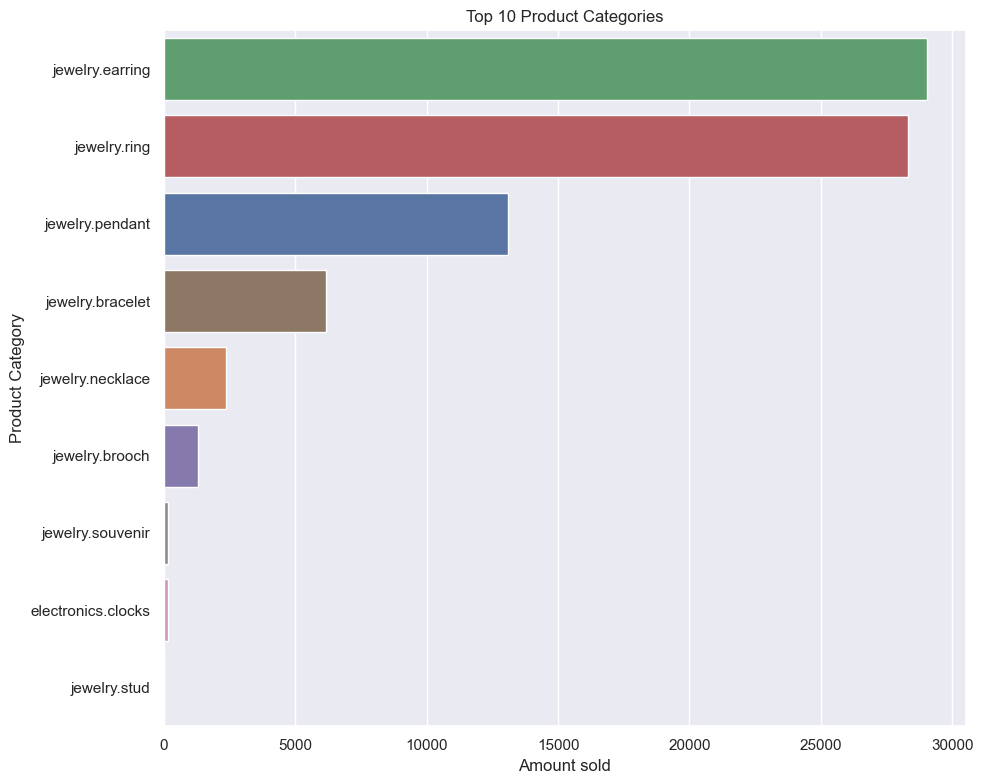

In [25]:
# bar chat for top product category (cateory_alias)
plt.figure(figsize = (10,8))
sns.countplot(data = data_with_drop_column, y = 'category_alias', order = data_with_drop_column["category_alias"].value_counts().head(10).index,palette = 'deep',hue = 'category_alias')
plt.title('Top 10 Product Categories')
plt.ylabel("Product Category")
plt.xlabel('Amount sold')
plt.tight_layout()
plt.show()
plt.close()

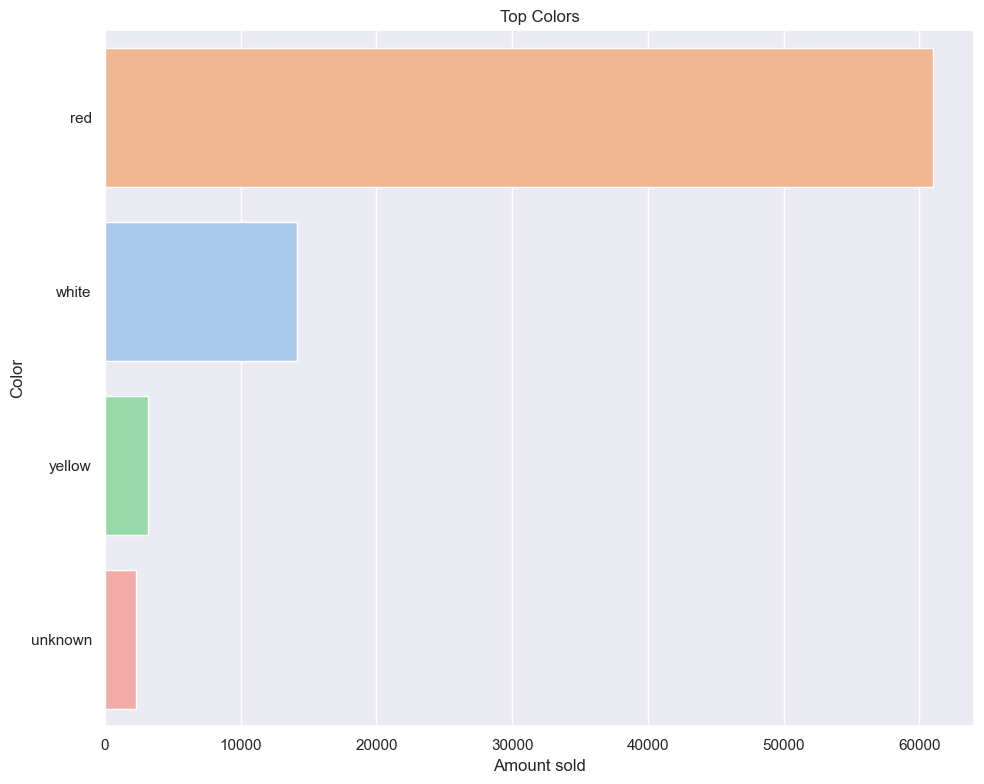

In [26]:
# bar chat for top Metal (main_metal)
plt.figure(figsize = (10,8))
sns.countplot(data = data_with_drop_column, y = 'main_color', order = data_with_drop_column["main_color"].value_counts().head(5).index,palette = 'pastel',hue = 'main_color')
plt.title("Top Colors")
plt.ylabel("Color")
plt.xlabel("Amount sold")
plt.tight_layout()
plt.show()
plt.close()

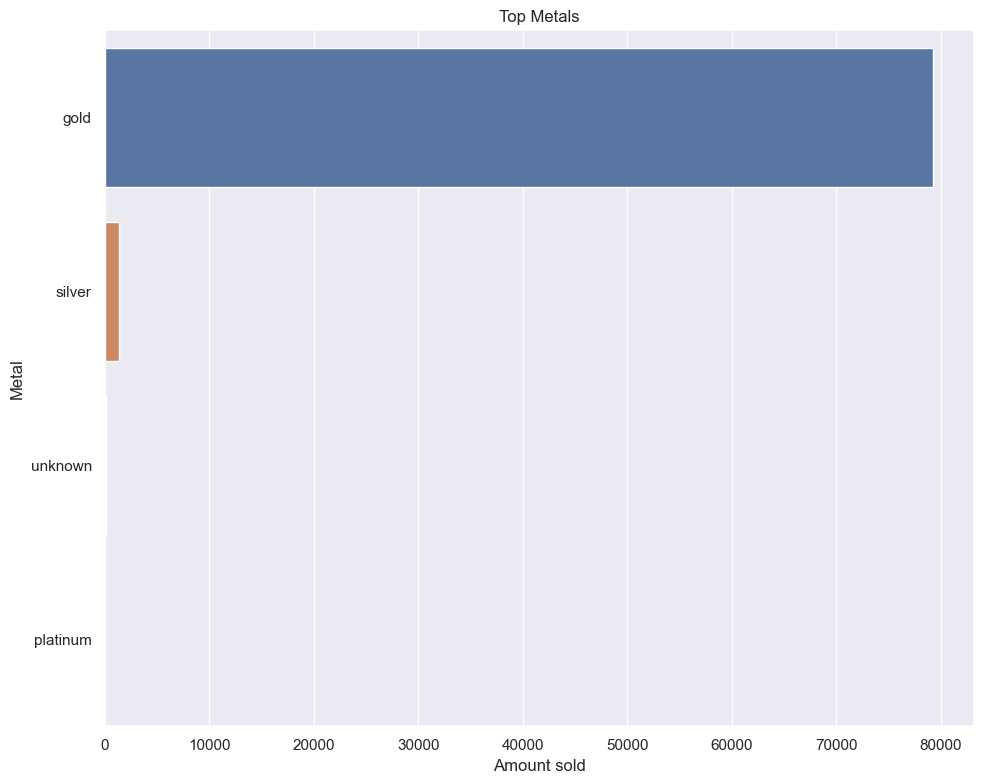

In [27]:
# bar chat for top metals (main_metal)
plt.figure(figsize = (10,8))
sns.countplot(data = data_with_drop_column, y = 'main_metal', order = data_with_drop_column["main_metal"].value_counts().head(5).index,palette = 'deep',hue = 'main_metal')
plt.title('Top Metals')
plt.ylabel('Metal')
plt.xlabel('Amount sold')
plt.tight_layout()
plt.show()
plt.close()

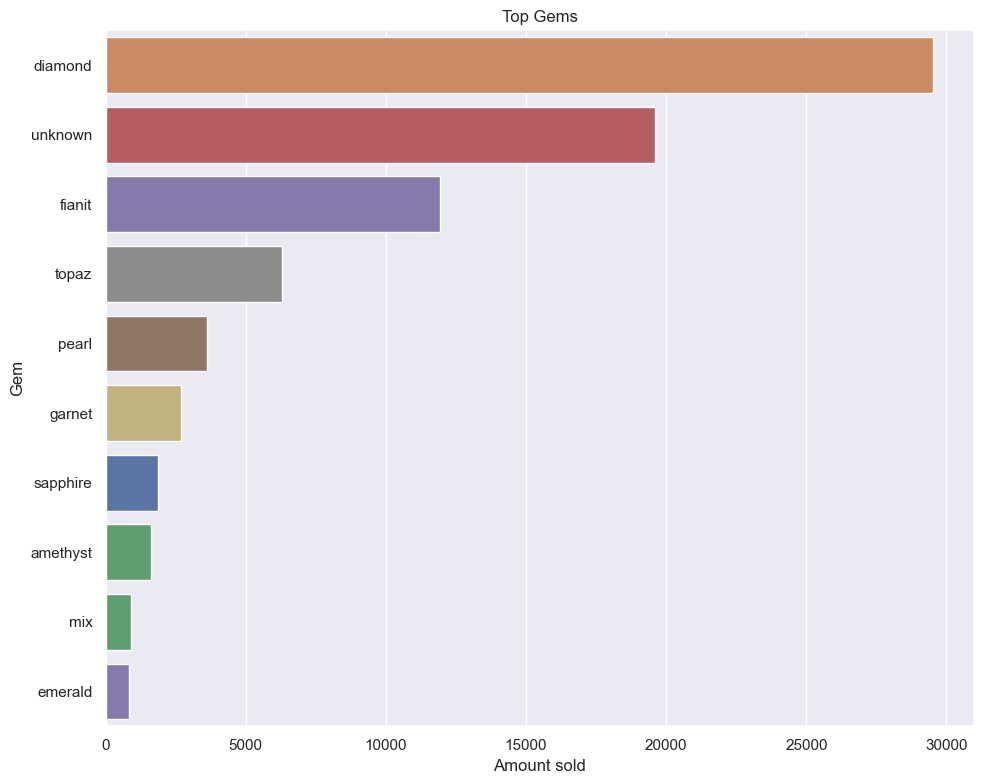

In [28]:
# bar chat for top gems (main_gem)
plt.figure(figsize = (10,8))
sns.countplot(data = data_with_drop_column, y = 'main_gem', order = data_with_drop_column["main_gem"].value_counts().head(10).index,palette = 'deep',hue = 'main_gem')
plt.title('Top Gems')
plt.ylabel('Gem')
plt.xlabel('Amount sold')
plt.tight_layout()
plt.show()
plt.close()

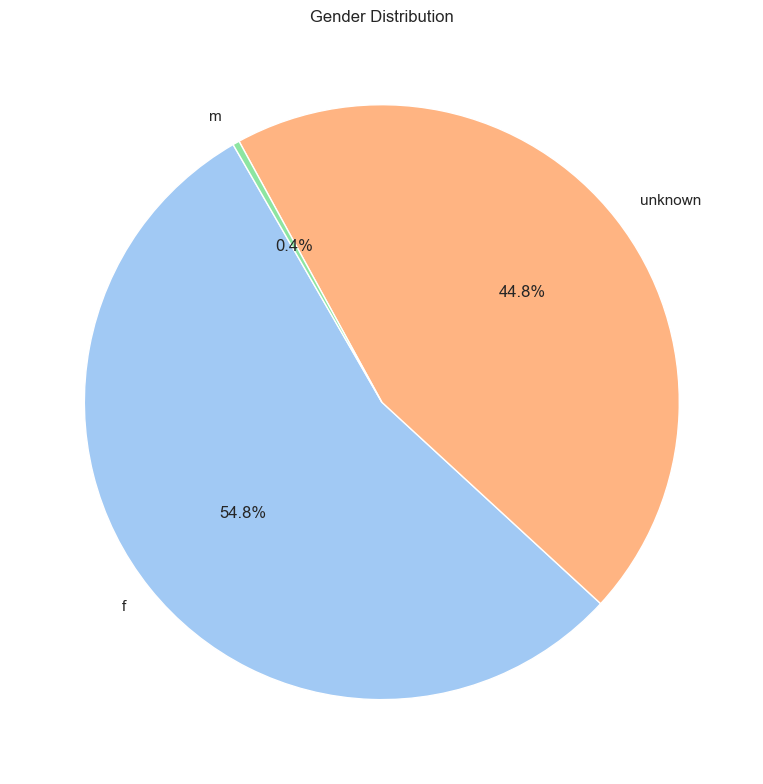

In [29]:
# visual analysis of product gender (gender)
plt.figure(figsize = (8,8))

plt.pie(data_with_drop_column["gender"].value_counts(),labels = data_with_drop_column["gender"].value_counts().index,autopct = '%1.1f%%', startangle = 120,colors = sns.color_palette('pastel'))
plt.title('Gender Distribution')

plt.tight_layout()
plt.show()
plt.close()

In [39]:
import seaborn as sns
from matplotlib import pyplot as plt

### Plotting Product Price against key variables

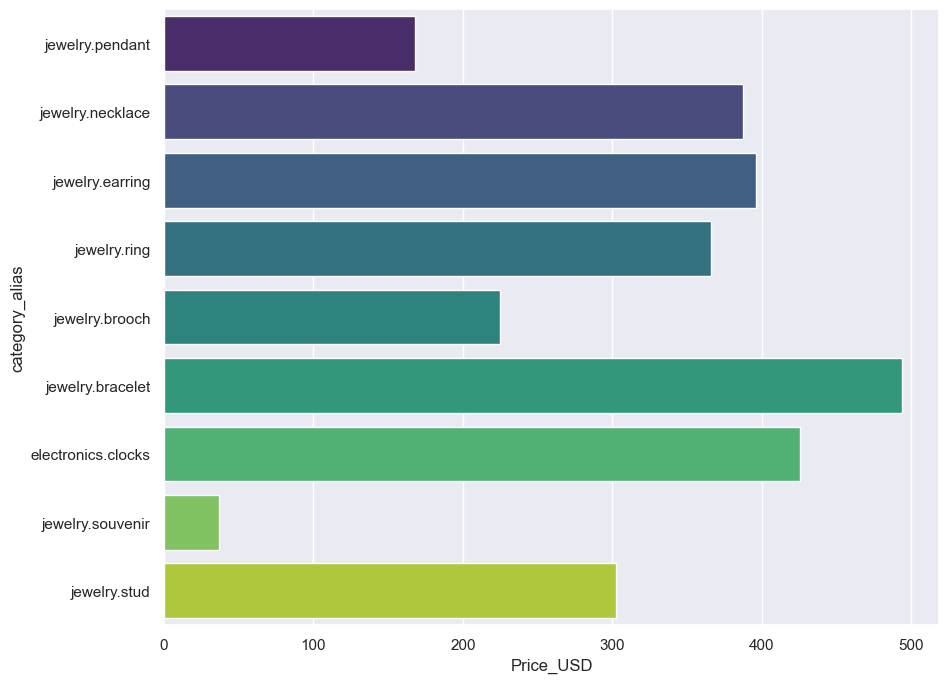

In [86]:
# 1. Bar chart of price against Product Category
plt.figure(figsize=(10,8))
sns.barplot(y= data_with_drop_column["category_alias"],
            x = data_with_drop_column["Price_USD"],
            data = data_with_drop_column,
            order = data_with_drop_column["category_alias"],
            palette = "viridis",
            hue ="category_alias",
            errorbar=None)

plt.show()

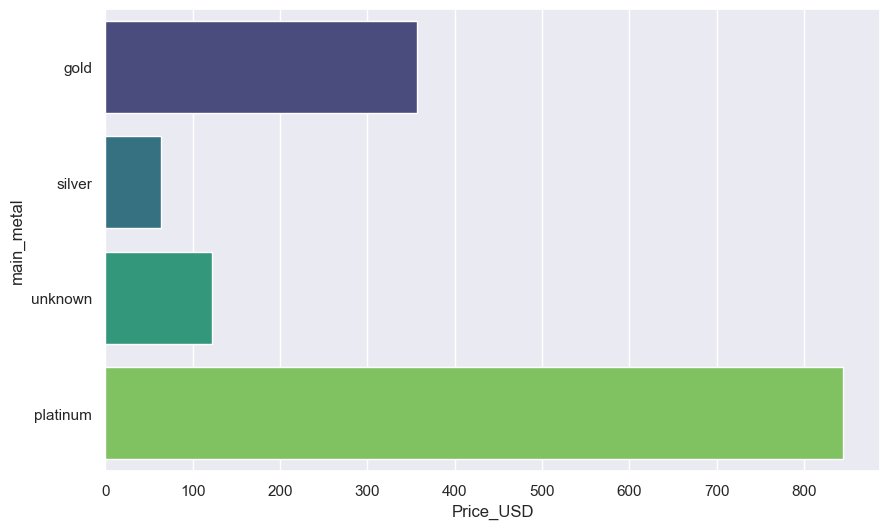

In [89]:
# 2. Bar chart of price against Main Metal
plt.figure(figsize=(10,6))
sns.barplot(y= data_with_drop_column["main_metal"],
            x = data_with_drop_column["Price_USD"],
            data = data_with_drop_column,
         
            palette = "viridis",
            hue ="main_metal",
            errorbar=None)

plt.show()

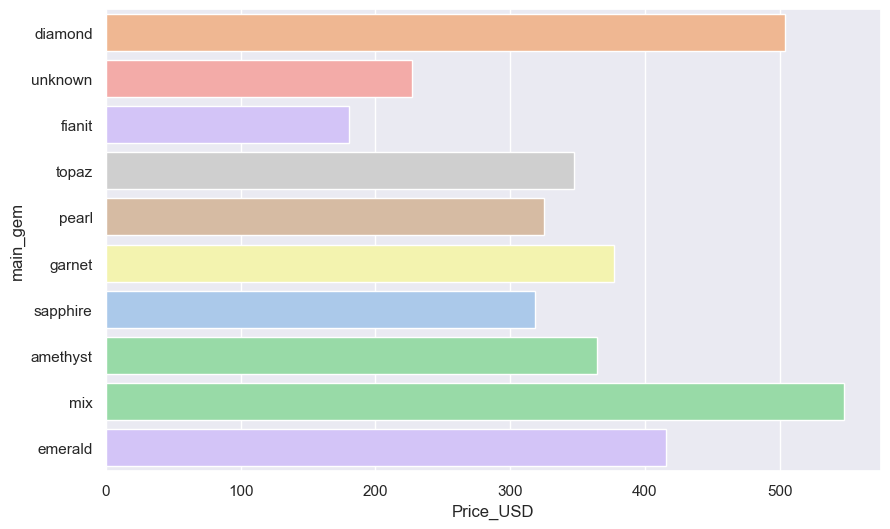

In [99]:
# 3. Bar chart of price against Main Metal
plt.figure(figsize=(10,6))
sns.barplot(y= data_with_drop_column["main_gem"],
            x = data_with_drop_column["Price_USD"],
            data = data_with_drop_column,
            order = data_with_drop_column["main_gem"].value_counts().head(10).index,
            palette = "pastel",
            hue ="main_gem",
            errorbar=None)

plt.show()